# Stage 03: Exploratory Data Analysis

This notebook describes the experiment population, group composition, outcomes, and notable patterns before formal A/B-test validation. It uses `data/processed/Hillstrom_clean.csv`, the Stage 02 analysis-ready dataset. EDA helps identify distributional features and questions for validation, but descriptive differences are not statistically supported treatment effects.

Stage 02 retained all 64,000 observations: there were no missing values, no justified row removals, retained exact duplicate rows, and logically consistent outcomes. `spend` remains zero-inflated and right-skewed. No dataset is modified here; no hypothesis tests, p-values, SRM testing, power analysis, causal models, or treatment recommendations are performed.

## 1. Load the analysis-ready data

All paths are project-relative. File hashes are retained to confirm neither the raw nor processed source changes during this notebook.

In [1]:
from hashlib import sha256
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

project_root = Path('.')
if not (project_root / 'data/processed/Hillstrom_clean.csv').exists():
    project_root = Path('..')

raw_path = project_root / 'data/raw/Hillstrom.csv'
processed_path = project_root / 'data/processed/Hillstrom_clean.csv'
figure_dir = project_root / 'outputs/figures'
table_dir = project_root / 'outputs/tables'

def file_sha256(path):
    return sha256(path.read_bytes()).hexdigest()

raw_hash_before = file_sha256(raw_path)
processed_hash_before = file_sha256(processed_path)
data = pd.read_csv(processed_path)
group_order = ['No E-Mail', 'Mens E-Mail', 'Womens E-Mail']
group_colors = ['#7F7F7F', '#4C78A8', '#F58518']

print(f'Loaded {len(data):,} observations and {data.shape[1]} columns from {processed_path}.')

Loaded 64,000 observations and 12 columns from ../data/processed/Hillstrom_clean.csv.


## 2. Overall population profile
The tables below describe likely customer characteristics across the complete experiment population.

In [2]:
customer_numeric_columns = ['recency', 'history']
customer_categorical_columns = ['history_segment', 'mens', 'womens', 'zip_code', 'newbie', 'channel']

population_numeric_summary = data[customer_numeric_columns].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]).T.rename(columns={'50%': 'median'})
display(population_numeric_summary)

for column in customer_categorical_columns:
    summary = data[column].value_counts(dropna=False).rename_axis(column).reset_index(name='count')
    summary['percentage'] = (summary['count'] / len(data) * 100).round(2)
    print(f'\n{column}')
    display(summary)

,count,mean,std,min,5%,25%,median,75%,95%,max
recency,64000.0,5.763734,3.507592,1.00,1.00,2.00,6.00,9.0000,11.0000,12.00
history,64000.0,242.085656,256.158608,29.99,29.99,64.66,158.11,325.6575,747.2625,3345.93



history_segment


,history_segment,count,percentage
0,1) $0 - $100,22970,35.89
1,2) $100 - $200,14254,22.27
2,3) $200 - $350,12289,19.20
3,4) $350 - $500,6409,10.01
4,5) $500 - $750,4911,7.67
5,"6) $750 - $1,000",1859,2.90
6,"7) $1,000 +",1308,2.04



mens


,mens,count,percentage
0,1,35266,55.1
1,0,28734,44.9


...

,zip_code,count,percentage
0,Surburban,28776,44.96
1,Urban,25661,40.10
2,Rural,9563,14.94



newbie


,newbie,count,percentage
0,1,32144,50.22
1,0,31856,49.78



channel


,channel,count,percentage
0,Web,28217,44.09
1,Phone,28021,43.78
2,Multichannel,7762,12.13


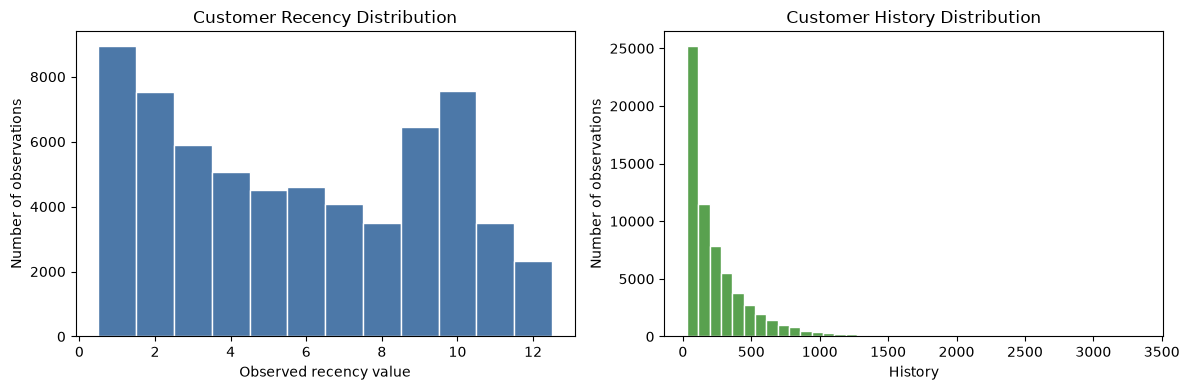

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(data['recency'], bins=np.arange(0.5, 13.5, 1), color='#4C78A8', edgecolor='white')
axes[0].set(title='Customer Recency Distribution', xlabel='Observed recency value', ylabel='Number of observations')
axes[1].hist(data['history'], bins=40, color='#59A14F', edgecolor='white')
axes[1].set(title='Customer History Distribution', xlabel='History', ylabel='Number of observations')
plt.tight_layout()
plt.show()

## 3. Treatment group overview
Observed group sizes are presented descriptively. No SRM test is performed in this notebook.

,Treatment Group,Sample Size,Population Share
0,No E-Mail,21306,33.29
1,Mens E-Mail,21307,33.29
2,Womens E-Mail,21387,33.42


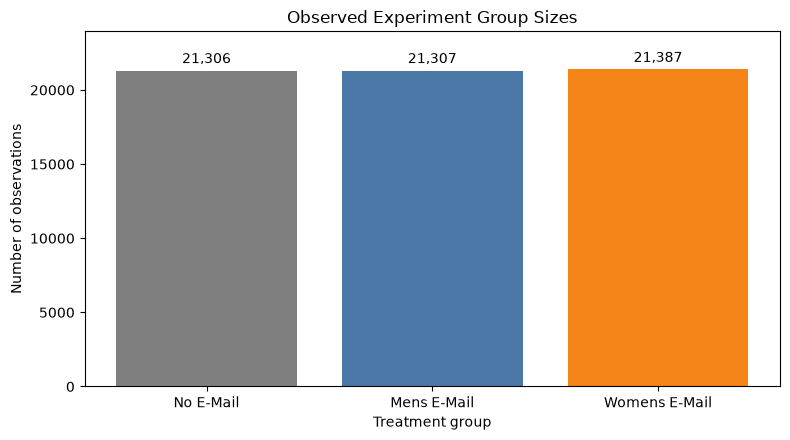

In [4]:
treatment_overview = data['segment'].value_counts().reindex(group_order).rename_axis('Treatment Group').reset_index(name='Sample Size')
treatment_overview['Population Share'] = (treatment_overview['Sample Size'] / len(data) * 100).round(2)
display(treatment_overview)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(treatment_overview['Treatment Group'], treatment_overview['Sample Size'], color=group_colors)
ax.bar_label(bars, labels=[f'{value:,}' for value in treatment_overview['Sample Size']], padding=3)
ax.set(title='Observed Experiment Group Sizes', xlabel='Treatment group', ylabel='Number of observations')
ax.set_ylim(0, treatment_overview['Sample Size'].max() * 1.12)
plt.tight_layout()
fig.savefig(figure_dir / 'treatment_group_sizes.png', dpi=160, bbox_inches='tight')
plt.show()

## 4. Baseline characteristics by treatment
These are descriptive comparisons of likely pre-treatment/customer characteristics. They flag features for later formal balance assessment; no significance tests are used here.

In [5]:
baseline_numeric = data.groupby('segment', observed=True)[['recency', 'history']].agg(['mean', 'median', 'std']).reindex(group_order)
display(baseline_numeric.round(2))

baseline_binary = data.groupby('segment', observed=True)[['mens', 'womens', 'newbie']].mean().reindex(group_order).mul(100).round(2)
baseline_binary.columns = [f'{column} = 1 (%)' for column in baseline_binary.columns]
display(baseline_binary)

for column in ['history_segment', 'zip_code', 'channel']:
    distribution = pd.crosstab(data[column], data['segment'], normalize='columns').reindex(columns=group_order).mul(100).round(2)
    print(f'\n{column}: percentage within each treatment group')
    display(distribution)

recency              history                
                 mean median   std    mean  median     std
segment                                                   
No E-Mail        5.75    5.0  3.50  240.88  156.66  252.74
Mens E-Mail      5.77    6.0  3.51  242.84  157.22  260.36
Womens E-Mail    5.77    6.0  3.51  242.54  160.09  255.33

,mens = 1 (%),womens = 1 (%),newbie = 1 (%)
segment,,,
No E-Mail,55.32,54.76,50.20
Mens E-Mail,55.09,55.14,50.15
Womens E-Mail,54.89,55.01,50.32



history_segment: percentage within each treatment group


segment,No E-Mail,Mens E-Mail,Womens E-Mail
history_segment,,,
1) $0 - $100,35.73,36.25,35.69
2) $100 - $200,22.70,22.02,22.10
3) $200 - $350,18.98,19.20,19.43
4) $350 - $500,9.97,9.84,10.23
5) $500 - $750,7.75,7.50,7.77
"6) $750 - $1,000",2.92,3.02,2.77
"7) $1,000 +",1.95,2.18,2.00



zip_code: percentage within each treatment group


segment,No E-Mail,Mens E-Mail,Womens E-Mail
zip_code,,,
Rural,14.73,15.22,14.87
Surburban,45.18,44.59,45.12
Urban,40.09,40.19,40.01



channel: percentage within each treatment group


segment,No E-Mail,Mens E-Mail,Womens E-Mail
channel,,,
Multichannel,12.23,12.09,12.06
Phone,43.78,43.37,44.20
Web,43.99,44.54,43.74


## 5. Visit outcome
Visit is reported overall and by observed group. Differences below are descriptive only and have not been tested statistically.

In [6]:
visit_overall = pd.DataFrame({
    'metric': ['Visitors', 'Non-visitors', 'Visit rate', 'Non-visit rate'],
    'value': [int(data['visit'].sum()), int((data['visit'] == 0).sum()), data['visit'].mean() * 100, (data['visit'] == 0).mean() * 100],
})
display(visit_overall)

visit_by_group = data.groupby('segment', observed=True)['visit'].agg(['size', 'sum', 'mean']).reindex(group_order).reset_index()
visit_by_group.columns = ['Treatment Group', 'Sample Size', 'Visitors', 'Visit Rate']
visit_by_group['Visit Rate'] = (visit_by_group['Visit Rate'] * 100).round(2)
display(visit_by_group)

,metric,value
0,Visitors,9394.000000
1,Non-visitors,54606.000000
2,Visit rate,14.678125
3,Non-visit rate,85.321875


,Treatment Group,Sample Size,Visitors,Visit Rate
0,No E-Mail,21306,2262,10.62
1,Mens E-Mail,21307,3894,18.28
2,Womens E-Mail,21387,3238,15.14


## 6. Conversion outcome
Conversion is likewise reported descriptively, without p-values or a treatment conclusion.

,metric,value
0,Conversions,578.000000
1,Non-conversions,63422.000000
2,Conversion rate,0.903125
3,Non-conversion rate,99.096875


,Treatment Group,Sample Size,Conversions,Conversion Rate
0,No E-Mail,21306,122,0.57
1,Mens E-Mail,21307,267,1.25
2,Womens E-Mail,21387,189,0.88


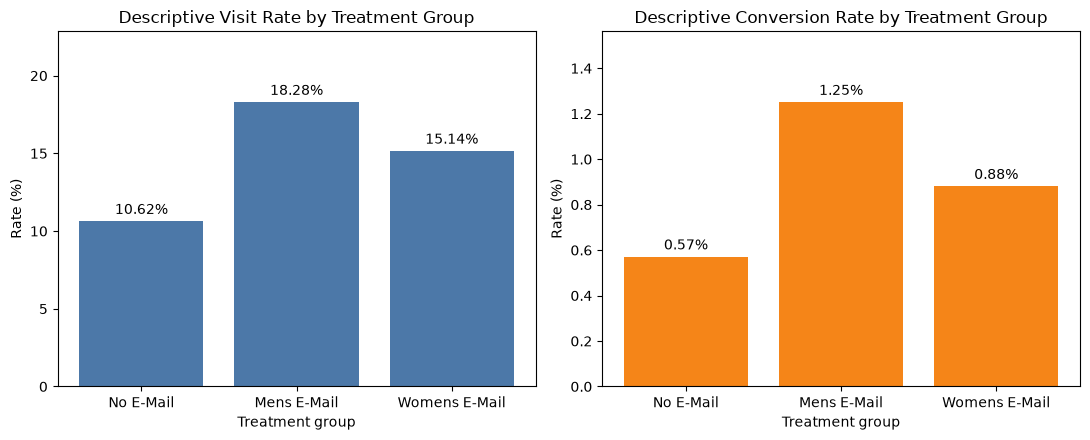

In [7]:
conversion_overall = pd.DataFrame({
    'metric': ['Conversions', 'Non-conversions', 'Conversion rate', 'Non-conversion rate'],
    'value': [int(data['conversion'].sum()), int((data['conversion'] == 0).sum()), data['conversion'].mean() * 100, (data['conversion'] == 0).mean() * 100],
})
display(conversion_overall)

conversion_by_group = data.groupby('segment', observed=True)['conversion'].agg(['size', 'sum', 'mean']).reindex(group_order).reset_index()
conversion_by_group.columns = ['Treatment Group', 'Sample Size', 'Conversions', 'Conversion Rate']
conversion_by_group['Conversion Rate'] = (conversion_by_group['Conversion Rate'] * 100).round(2)
display(conversion_by_group)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, summary, metric, color in zip(axes, [visit_by_group, conversion_by_group], ['Visit Rate', 'Conversion Rate'], ['#4C78A8', '#F58518']):
    bars = ax.bar(summary['Treatment Group'], summary[metric], color=color)
    ax.bar_label(bars, labels=[f'{value:.2f}%' for value in summary[metric]], padding=3)
    ax.set(title=f'Descriptive {metric} by Treatment Group', xlabel='Treatment group', ylabel='Rate (%)')
    ax.set_ylim(0, summary[metric].max() * 1.25)
plt.tight_layout()
fig.savefig(figure_dir / 'outcome_rates_by_treatment.png', dpi=160, bbox_inches='tight')
plt.show()

## 7. Spend outcome
`spend` is examined both including and excluding zeros. No high-spend observations are removed or winsorized.

,metric,value
0,Total spend,67258.13
1,Mean spend per experimental unit,1.05
2,Median spend,0.00
3,Zero-spend percentage,99.10
4,Positive-spend count,578.00
5,Mean spend among positive spenders,116.36
6,Median spend among positive spenders,80.80
7,95th percentile of positive spend,362.20
8,99th percentile of positive spend,499.00
9,Maximum spend,499.00


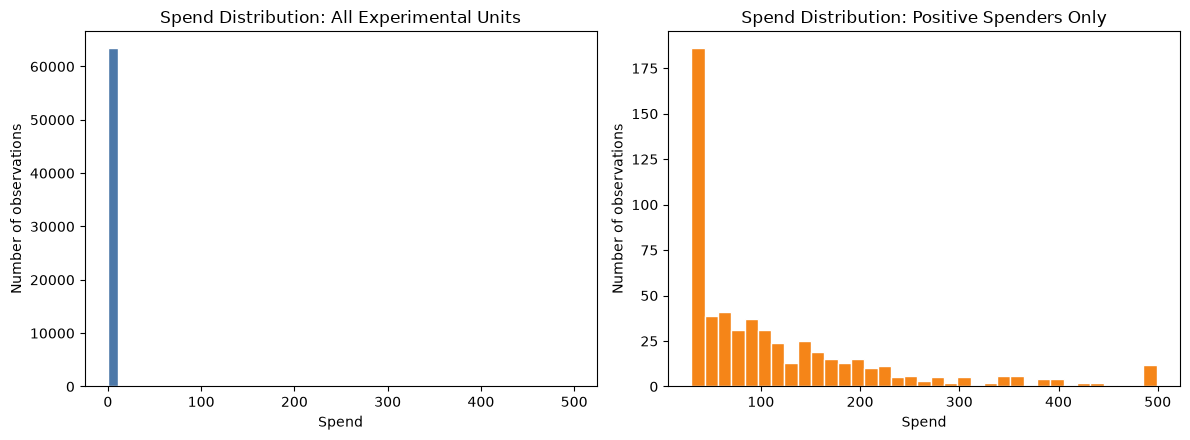

In [8]:
positive_spend = data.loc[data['spend'] > 0, 'spend']
spend_overall = pd.DataFrame({
    'metric': ['Total spend', 'Mean spend per experimental unit', 'Median spend', 'Zero-spend percentage', 'Positive-spend count', 'Mean spend among positive spenders', 'Median spend among positive spenders', '95th percentile of positive spend', '99th percentile of positive spend', 'Maximum spend'],
    'value': [data['spend'].sum(), data['spend'].mean(), data['spend'].median(), (data['spend'].eq(0).mean() * 100), len(positive_spend), positive_spend.mean(), positive_spend.median(), positive_spend.quantile(.95), positive_spend.quantile(.99), data['spend'].max()],
})
display(spend_overall.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(data['spend'], bins=45, color='#4C78A8', edgecolor='white')
axes[0].set(title='Spend Distribution: All Experimental Units', xlabel='Spend', ylabel='Number of observations')
axes[1].hist(positive_spend, bins=35, color='#F58518', edgecolor='white')
axes[1].set(title='Spend Distribution: Positive Spenders Only', xlabel='Spend', ylabel='Number of observations')
plt.tight_layout()
fig.savefig(figure_dir / 'spend_distributions.png', dpi=160, bbox_inches='tight')
plt.show()

## 8. Spend by treatment group
Means and medians are shown together because the overall distribution is highly skewed and zero-inflated. These comparisons are descriptive only.

,Treatment Group,Total Spend,Mean Spend,Median Spend,Positive-Spend Rate,Mean Positive Spend,Median Positive Spend
0,No E-Mail,13908.33,0.65,0.0,0.57,114.00,88.36
1,Mens E-Mail,30311.69,1.42,0.0,1.25,113.53,66.98
2,Womens E-Mail,23038.11,1.08,0.0,0.88,121.89,94.71


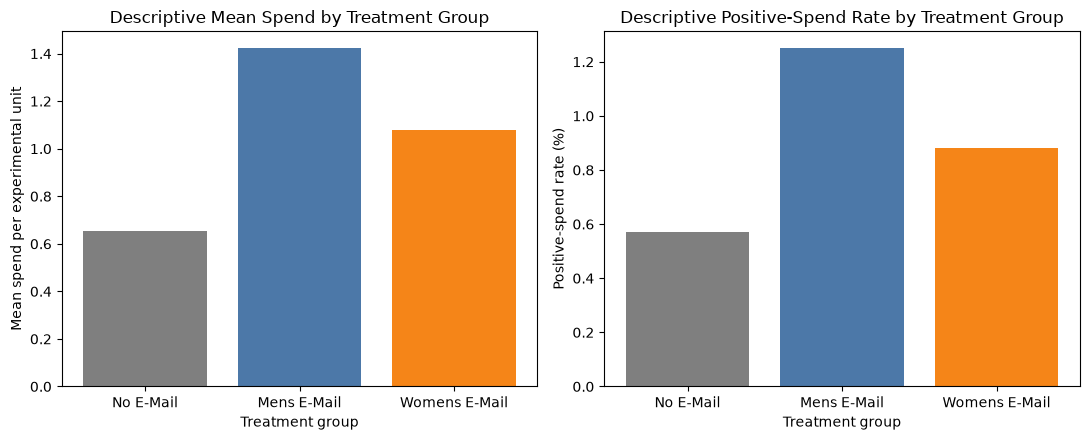

In [9]:
spend_by_group = data.groupby('segment', observed=True).agg(
    **{'Total Spend': ('spend', 'sum'), 'Mean Spend': ('spend', 'mean'), 'Median Spend': ('spend', 'median'), 'Positive-Spend Rate': ('spend', lambda values: (values > 0).mean()), 'Mean Positive Spend': ('spend', lambda values: values[values > 0].mean()), 'Median Positive Spend': ('spend', lambda values: values[values > 0].median())}
).reindex(group_order).reset_index().rename(columns={'segment': 'Treatment Group'})
spend_by_group['Positive-Spend Rate'] = (spend_by_group['Positive-Spend Rate'] * 100).round(2)
display(spend_by_group.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(spend_by_group['Treatment Group'], spend_by_group['Mean Spend'], color=group_colors)
axes[0].set(title='Descriptive Mean Spend by Treatment Group', xlabel='Treatment group', ylabel='Mean spend per experimental unit')
axes[1].bar(spend_by_group['Treatment Group'], spend_by_group['Positive-Spend Rate'], color=group_colors)
axes[1].set(title='Descriptive Positive-Spend Rate by Treatment Group', xlabel='Treatment group', ylabel='Positive-spend rate (%)')
plt.tight_layout()
fig.savefig(figure_dir / 'spend_by_treatment.png', dpi=160, bbox_inches='tight')
plt.show()

## 9. Outcome funnel
The Stage 02 consistency checks establish the observed sequence: experimental unit → visit → conversion → positive spend. Rates below use explicit denominators and are not causal interpretations.

,Stage,Count,Rate among all experimental units (%),Rate conditional on prior stage (%)
0,Experimental units,64000,100.00,100.00
1,Visits,9394,14.68,14.68
2,Conversions,578,0.90,6.15
3,Positive spend,578,0.90,100.00


,Experimental Units,Visits,Conversions,Positive Spend,Visit Rate among Units (%),Conversion Rate among Units (%),Conversion Rate among Visits (%),Positive-Spend Rate among Units (%)
segment,,,,,,,,
No E-Mail,21306,2262,122,122,10.62,0.57,5.39,0.57
Mens E-Mail,21307,3894,267,267,18.28,1.25,6.86,1.25
Womens E-Mail,21387,3238,189,189,15.14,0.88,5.84,0.88


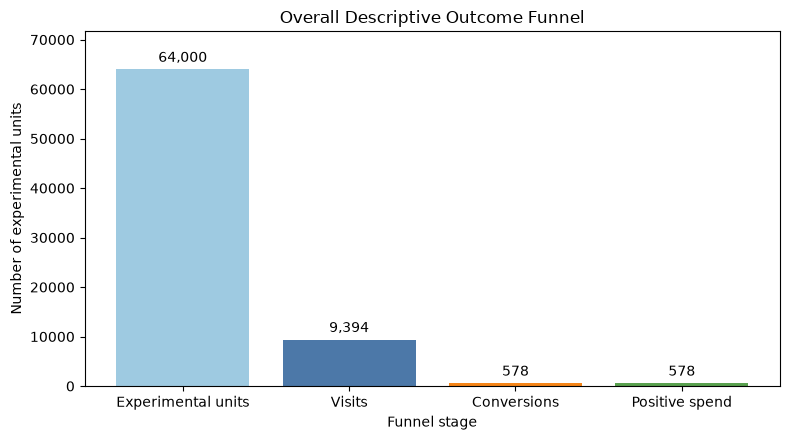

In [10]:
overall_funnel = pd.DataFrame({
    'Stage': ['Experimental units', 'Visits', 'Conversions', 'Positive spend'],
    'Count': [len(data), int(data.visit.sum()), int(data.conversion.sum()), int((data.spend > 0).sum())],
})
overall_funnel['Rate among all experimental units (%)'] = (overall_funnel['Count'] / len(data) * 100).round(2)
overall_funnel['Rate conditional on prior stage (%)'] = [100, data.visit.mean() * 100, data.conversion.sum() / data.visit.sum() * 100, (data.spend > 0).sum() / data.conversion.sum() * 100]
display(overall_funnel.round(2))

group_funnel = data.groupby('segment', observed=True).agg(
    **{'Experimental Units': ('segment', 'size'), 'Visits': ('visit', 'sum'), 'Conversions': ('conversion', 'sum'), 'Positive Spend': ('spend', lambda values: (values > 0).sum())}
).reindex(group_order)
group_funnel['Visit Rate among Units (%)'] = (group_funnel['Visits'] / group_funnel['Experimental Units'] * 100).round(2)
group_funnel['Conversion Rate among Units (%)'] = (group_funnel['Conversions'] / group_funnel['Experimental Units'] * 100).round(2)
group_funnel['Conversion Rate among Visits (%)'] = (group_funnel['Conversions'] / group_funnel['Visits'] * 100).round(2)
group_funnel['Positive-Spend Rate among Units (%)'] = (group_funnel['Positive Spend'] / group_funnel['Experimental Units'] * 100).round(2)
display(group_funnel)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(overall_funnel['Stage'], overall_funnel['Count'], color=['#9ECAE1', '#4C78A8', '#F58518', '#59A14F'])
ax.bar_label(bars, labels=[f'{count:,}' for count in overall_funnel['Count']], padding=3)
ax.set(title='Overall Descriptive Outcome Funnel', xlabel='Funnel stage', ylabel='Number of experimental units')
ax.set_ylim(0, len(data) * 1.12)
plt.tight_layout()
fig.savefig(figure_dir / 'overall_outcome_funnel.png', dpi=160, bbox_inches='tight')
plt.show()

## 10. Customer-segment exploration
The following concise profile identifies customer dimensions with potentially useful descriptive variation. It does not test subgroups or estimate heterogeneous treatment effects.

In [11]:
segment_profiles = []
for variable in ['channel', 'zip_code', 'newbie', 'history_segment', 'mens', 'womens']:
    profile = data.groupby(variable, observed=True).agg(
        Sample_Size=(variable, 'size'), Visit_Rate=('visit', 'mean'), Conversion_Rate=('conversion', 'mean'), Mean_Spend=('spend', 'mean')
    ).reset_index().rename(columns={variable: 'Segment'})
    profile.insert(0, 'Characteristic', variable)
    segment_profiles.append(profile)

customer_segment_profile = pd.concat(segment_profiles, ignore_index=True)
customer_segment_profile['Visit_Rate'] = (customer_segment_profile['Visit_Rate'] * 100).round(2)
customer_segment_profile['Conversion_Rate'] = (customer_segment_profile['Conversion_Rate'] * 100).round(2)
customer_segment_profile['Mean_Spend'] = customer_segment_profile['Mean_Spend'].round(2)
display(customer_segment_profile)

,Characteristic,Segment,Sample_Size,Visit_Rate,Conversion_Rate,Mean_Spend
0,channel,Multichannel,7762,17.17,1.26,1.40
1,channel,Phone,28021,12.72,0.77,0.91
2,channel,Web,28217,15.94,0.93,1.10
3,zip_code,Rural,9563,18.81,1.12,1.19
4,zip_code,Surburban,28776,13.99,0.83,0.99
5,zip_code,Urban,25661,13.90,0.90,1.06
6,newbie,0,31856,17.31,1.01,1.17
7,newbie,1,32144,12.07,0.80,0.94
8,history_segment,1) $0 - $100,22970,12.35,0.71,0.91
9,history_segment,2) $100 - $200,14254,12.78,0.69,0.81


## 11. Temporal analysis
No actual timestamp or date variable is present in this dataset. Temporal experiment analysis therefore cannot assess trends during the experiment, time-dependent anomalies, seasonality, or duration-related changes. No time variable is inferred or created.

## 12. Correlation and relationship exploration
Pearson correlations provide a compact descriptive view of numeric and binary variables. They do not establish causation; correlations involving binary outcomes, zero-inflated `spend`, and skewed spend should be interpreted cautiously.

,history,recency,visit,conversion,spend
history,1.000,-0.247,0.065,0.029,0.022
recency,-0.247,1.000,-0.075,-0.024,-0.016
visit,0.065,-0.075,1.000,0.230,0.169
conversion,0.029,-0.024,0.230,1.000,0.732
spend,0.022,-0.016,0.169,0.732,1.000


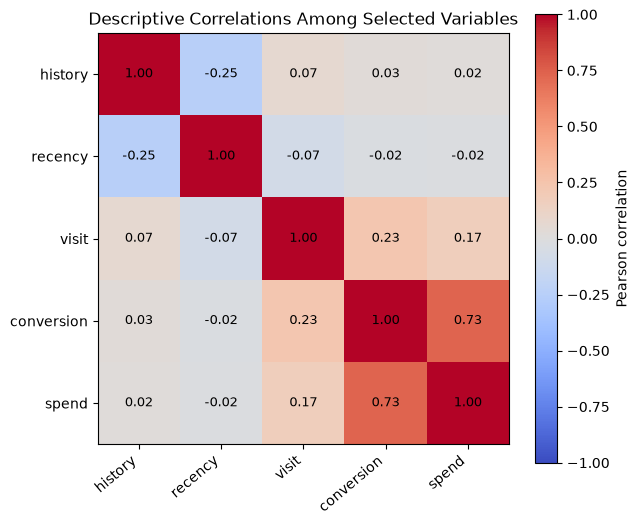

In [12]:
relationship_columns = ['history', 'recency', 'visit', 'conversion', 'spend']
correlation_matrix = data[relationship_columns].corr()
display(correlation_matrix.round(3))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
image = ax.imshow(correlation_matrix, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(relationship_columns)), relationship_columns, rotation=40, ha='right')
ax.set_yticks(range(len(relationship_columns)), relationship_columns)
for row in range(len(relationship_columns)):
    for column in range(len(relationship_columns)):
        ax.text(column, row, f'{correlation_matrix.iloc[row, column]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(image, ax=ax, label='Pearson correlation')
ax.set_title('Descriptive Correlations Among Selected Variables')
plt.tight_layout()
plt.show()

## 13. EDA summary table
This experiment-level table is descriptive only and is saved for later reporting.

In [13]:
eda_summary = data.groupby('segment', observed=True).agg(
    **{'Sample Size': ('segment', 'size'), 'Visit Rate': ('visit', 'mean'), 'Conversion Rate': ('conversion', 'mean'), 'Mean Spend': ('spend', 'mean'), 'Median Spend': ('spend', 'median'), 'Positive-Spend Rate': ('spend', lambda values: (values > 0).mean())}
).reindex(group_order).reset_index().rename(columns={'segment': 'Treatment Group'})
eda_summary['Population Share'] = (eda_summary['Sample Size'] / len(data) * 100).round(2)
for column in ['Visit Rate', 'Conversion Rate', 'Positive-Spend Rate']:
    eda_summary[column] = (eda_summary[column] * 100).round(2)
eda_summary[['Mean Spend', 'Median Spend']] = eda_summary[['Mean Spend', 'Median Spend']].round(2)
eda_summary = eda_summary[['Treatment Group', 'Sample Size', 'Population Share', 'Visit Rate', 'Conversion Rate', 'Mean Spend', 'Median Spend', 'Positive-Spend Rate']]
display(eda_summary)
eda_summary.to_csv(table_dir / 'experiment_descriptive_summary.csv', index=False)
print('Saved outputs/tables/experiment_descriptive_summary.csv')

,Treatment Group,Sample Size,Population Share,Visit Rate,Conversion Rate,Mean Spend,Median Spend,Positive-Spend Rate
0,No E-Mail,21306,33.29,10.62,0.57,0.65,0.0,0.57
1,Mens E-Mail,21307,33.29,18.28,1.25,1.42,0.0,1.25
2,Womens E-Mail,21387,33.42,15.14,0.88,1.08,0.0,0.88


Saved outputs/tables/experiment_descriptive_summary.csv


## Stage 03 Findings

The population contains 64,000 observations allocated almost evenly across the three observed groups. Customer-history, recency, merchandise indicators, newness, geography, and channel distributions are descriptively similar across groups; minor differences should still be formally assessed during Stage 04 rather than assumed balanced.

Overall, 14.68% of experimental units visited, 0.90% converted, and mean spend was 1.05 per unit. The descriptive group-level rates and spend summaries differ, but no formal treatment-effect conclusion is made. `spend` is extremely zero-inflated (99.10% zero) and its positive values are strongly right-skewed, so medians and positive-spender summaries are shown alongside means.

Channel, geography, newness, and history segment show useful descriptive outcome variation and may be candidates for carefully scoped later exploration. Key limitations are the lack of a timestamp, no explicit customer identifier, ambiguity around duplicate observed records, unknown measurement windows, and non-normal/zero-inflated outcomes. Stage 04 should address assignment validation and baseline balance; this EDA does not establish causal effects, treatment winners, or business recommendations.

## 14. File-integrity confirmation

In [14]:
raw_hash_after = file_sha256(raw_path)
processed_hash_after = file_sha256(processed_path)
print(f'Raw dataset unchanged during notebook execution: {raw_hash_before == raw_hash_after}')
print(f'Processed dataset unchanged during notebook execution: {processed_hash_before == processed_hash_after}')

Raw dataset unchanged during notebook execution: True
Processed dataset unchanged during notebook execution: True
